# RiMEA 12a: Position of Goal Cells

This notebook demonstrates the current public implementation of RiMEA Test 12a. We load one base two-room scenario, move the goal in room 2 by a distance `a`, and measure how long room 1 needs to empty through the bottleneck.

The room-1 evacuation time is measured at a vertical PedPy measurement line placed at `x = 10`, directly in the wall opening between the rooms. For each scenario, we use the last crossing time at that line as the evacuation time of room 1.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pedpy

from core.scenario import load_scenario, run_scenario


In [2]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "xtick.color": "#1d1d1d",
        "ytick.color": "#1d1d1d",
        "font.size": 11,
    }
)

SCENARIO_DIR = Path("scenarios") / "rimea-12a-goal-position"
A_VALUES = [0.2, *range(1, 10), 9.8]
MEASUREMENT_LINE = pedpy.MeasurementLine([(10.0, 4.5), (10.0, 5.5)])
SAMPLE_A_VALUES = [0.2, 5, 9.8]
SWEEP_SEEDS = [40, 41, 42]


## Load the Base Scenario

The scenario directory contains the shared two-room geometry and the initial crowd distribution. The notebook deep-copies the loaded raw scenario before moving the goal, so each run stays independent.

In [3]:
base_scenario = load_scenario(str(SCENARIO_DIR))
print(base_scenario.summary())

Scenario: /Users/chraibi/workspace/PedestrianDynamics/Web-Based-Jupedsim-issues/scripts/scenarios/rimea-12a-goal-position
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~50
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 50 agents


## Helper Functions

We represent the goal as a thin exit strip inside room 2. The left edge of that strip is placed at `x = 10.2 + a`, but we keep the sweep strictly inside room 2, from `a = 0.2` to `a = 9.8`.

In [4]:
def make_exit(distance_a: float) -> dict:
    left_x = 10.2 + float(distance_a)
    right_x = left_x + 0.2
    return {
        "jps-exits_0": {
            "type": "polygon",
            "coordinates": [[left_x, 0], [right_x, 0], [right_x, 10], [left_x, 10], [left_x, 0]],
            "enable_throughput_throttling": False,
            "max_throughput": 0,
        }
    }


def room1_evacuation_time(traj: pedpy.TrajectoryData):
    nt, crossing_frames = pedpy.compute_n_t(
        traj_data=traj,
        measurement_line=MEASUREMENT_LINE,
    )
    if len(crossing_frames) == 0:
        raise ValueError("No agents crossed the room-1 measurement line.")
    last_crossing_frame = int(crossing_frames["frame"].max())
    return nt, crossing_frames, last_crossing_frame / traj.frame_rate


def run_goal_variant(base, distance_a: float, seed: int = 42) -> dict:
    variant = base.copy(source_path=f"rimea-12a-a{distance_a}")
    variant.raw["exits"] = make_exit(distance_a)
    result = run_scenario(variant, seed=seed)
    traj = pedpy.TrajectoryData(
        result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy(),
        frame_rate=result.frame_rate,
    )
    nt, crossing_frames, room1_time = room1_evacuation_time(traj)
    metrics = dict(result.metrics)
    metrics["room1_evacuation_time"] = room1_time
    result.cleanup()
    return {
        "a": distance_a,
        "trajectory": traj,
        "walkable_area": pedpy.WalkableArea(variant.walkable_polygon),
        "goal": variant.raw["exits"]["jps-exits_0"]["coordinates"],
        "nt": nt,
        "crossing_frames": crossing_frames,
        "metrics": metrics,
        "room1_evacuation_time": room1_time,
    }


## Run the Goal-Position Sweep

The trajectory plots below use one deterministic run per distance. For the final dependence plot, we average over three seeds to reduce noise in the tail of the curve.

In [5]:
%%capture
runs = [run_goal_variant(base_scenario, distance_a, seed=42) for distance_a in A_VALUES]
sweep_runs = []
for distance_a in A_VALUES:
    seed_times = [
        run_goal_variant(base_scenario, distance_a, seed=seed)["room1_evacuation_time"]
        for seed in SWEEP_SEEDS
    ]
    sweep_runs.append(
        {
            "a": distance_a,
            "mean_room1_time": float(np.mean(seed_times)),
            "std_room1_time": float(np.std(seed_times)),
            "seed_times": seed_times,
        }
    )

summary_rows = [
    {
        "a_m": run["a"],
        "mean_room1_evacuation_time_s": round(run["mean_room1_time"], 2),
        "std_room1_evacuation_time_s": round(run["std_room1_time"], 2),
        "seed_times_s": [round(value, 2) for value in run["seed_times"]],
    }
    for run in sweep_runs
]
summary_rows

## Plot Geometries and Trajectories for Selected Distances

The three panels below show how the goal moves through room 2. The dashed line is the PedPy measurement line at `x = 10`, and the green strip is the goal location for that scenario.

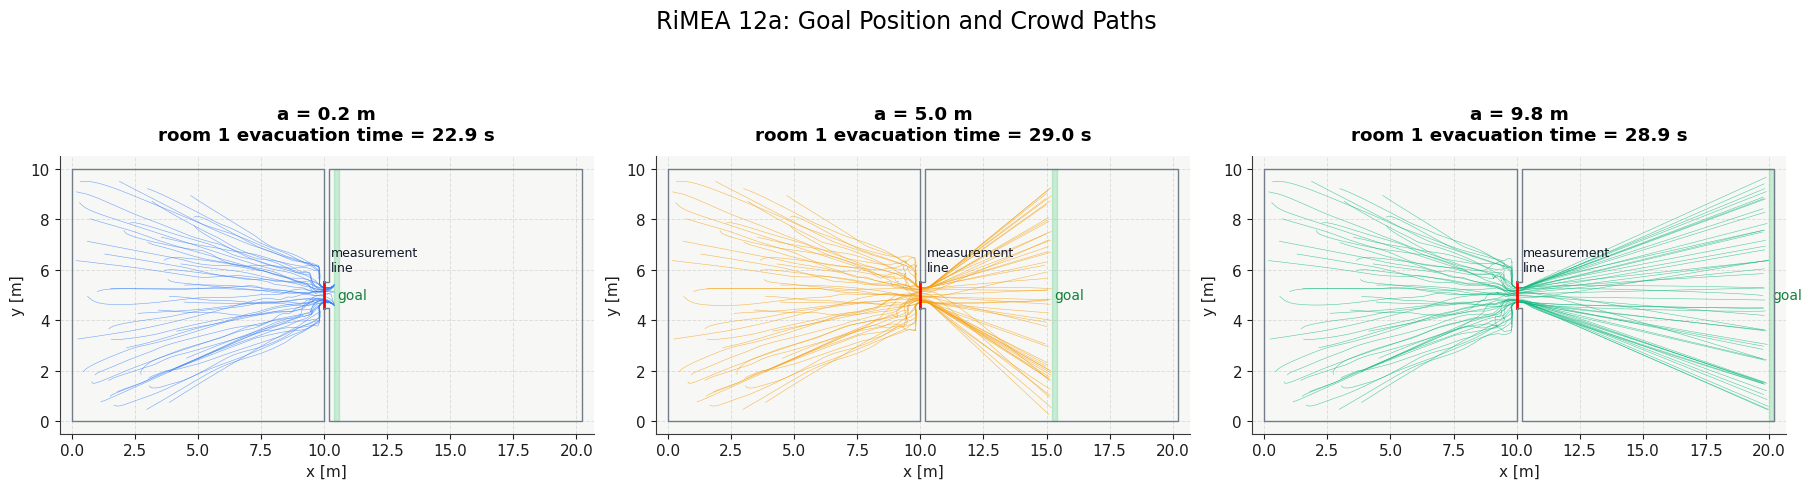

In [6]:
selected_runs = [run for run in runs if run["a"] in SAMPLE_A_VALUES]
trajectory_colors = {0.2: "#3B82F6", 5: "#F59E0B", 9.8: "#10B981"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

for ax, run in zip(axes, selected_runs):
    color = trajectory_colors[run["a"]]
    pedpy.plot_measurement_setup(
        traj=run["trajectory"],
        walkable_area=run["walkable_area"],
        measurement_lines=[MEASUREMENT_LINE],
        axes=ax,
        traj_alpha=0.72,
        traj_width=0.4,
        ml_width=2,
        ml_alpha=0.2,
        traj_color=color,
        ml_color="red",
    ).set_aspect("equal")
    goal_xy = np.asarray(run["goal"])
    ax.plot(goal_xy[:2, 0], goal_xy[:2, 1], alpha=0)
    ax.fill(goal_xy[:, 0], goal_xy[:, 1], color="#22C55E", alpha=0.22)
    ax.text(10.25, 5.85, "measurement\nline", color="#111827", fontsize=9, va="bottom")
    ax.text(goal_xy[0, 0] + 0.12, 5.0, "goal", color="#15803D", fontsize=10, va="center")
    ax.set_title(
        f"a = {run['a']:.1f} m\n"
        f"room 1 evacuation time = {run['room1_evacuation_time']:.1f} s",
        pad=12,
    )
    ax.set_xlim(-0.5, 20.7)
    ax.set_ylim(-0.5, 10.5)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("RiMEA 12a: Goal Position and Crowd Paths", fontsize=17, y=1.02)
plt.show()

## Plot Room-1 Evacuation Time vs. Goal Distance

The chart below shows the mean time when the last agent from room 1 crosses the measurement line at `x = 10`, plotted against the goal distance `a` in room 2. The error bars show the standard deviation across the three seeds in `SWEEP_SEEDS`.

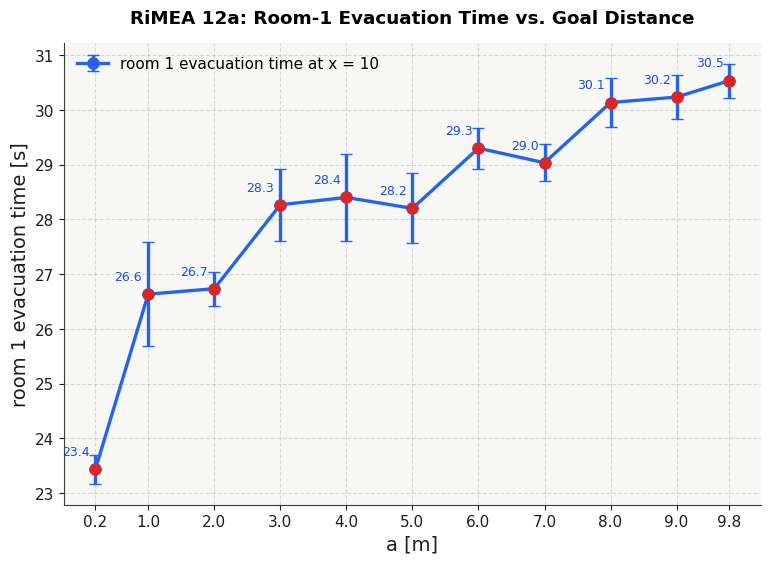

In [9]:
a_values = np.array([run["a"] for run in sweep_runs], dtype=float)
room1_times = np.array([run["mean_room1_time"] for run in sweep_runs], dtype=float)
room1_std = np.array([run["std_room1_time"] for run in sweep_runs], dtype=float)

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    a_values,
    room1_times,
    yerr=room1_std,
    color="#2563EB",
    linewidth=2.4,
    marker="o",
    markersize=8,
    capsize=4,
    label="room 1 evacuation time at x = 10",
)
ax.scatter(a_values, room1_times, color="#DC2626", s=60, zorder=3)

for a_value, evac_time in zip(a_values, room1_times):
    ax.annotate(
        f"{evac_time:.1f}",
        (a_value-0.3, evac_time),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        color="#1D4ED8",
        fontsize=9,
    )

ax.set_title("RiMEA 12a: Room-1 Evacuation Time vs. Goal Distance", pad=14)
ax.set_xlabel("a [m]", fontsize=14)
ax.set_ylabel("room 1 evacuation time [s]", fontsize=14)
ax.set_xticks(a_values)
ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper left")
plt.show()